### Build a Basic Chatbot with Langgraph(GRAPH API)

In [32]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [33]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # in this case, it appends messages to the list, rather than overwriting them
    messages: Annotated[list, add_messages]



In [39]:
import os
from dotenv import load_dotenv
load_dotenv()
Groq_API_KEY=os.environ["GROQ_API_KEY"]

python-dotenv could not parse statement starting at line 1


In [56]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "openai/gpt-oss-120b",
    model_provider="groq"
)

response = llm.invoke(
    "What is the date today? And why is it a special day for India?"
)

print(response.content)

**Today’s date:** **5 October 2026**  

---

## Why 5 October is a special day for India  

### 1. World Teachers’ Day (observed worldwide, including India)  
- **What it is:** 5 October is designated by UNESCO as *World Teachers’ Day*. The day honors the teaching profession and highlights the vital role teachers play in shaping societies.  
- **Why it matters in India:**  
  - **Education as a national priority:** The Indian Constitution guarantees free and compulsory education for children (Article 21‑A). Teachers are therefore seen as the front‑line agents of this constitutional promise.  
  - **National celebrations:** Across the country, schools, colleges, universities, and education departments organize special programmes—award ceremonies, cultural performances, seminars on pedagogy, and “Thank‑a‑Teacher” campaigns.  
  - **Policy focus:** The Ministry of Education often uses the occasion to announce new initiatives (e.g., teacher‑training schemes, digital‑learning pilots, salary

In [57]:
graph_builder = StateGraph(State)

In [58]:
## Node functionality

def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot) # Node name, function

## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## Compile the graph
graph = graph_builder.compile()

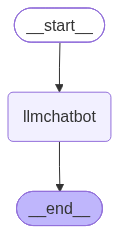

In [59]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Hey")


In [60]:
response = graph.invoke({"messages":"Hi"})

In [61]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [62]:
for event in graph.stream({"messages":"Hi how are you"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="Hello! I'm doing great, thank you for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'The user says "Hi how are you". This is a simple greeting. The assistant should respond politely. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 75, 'total_tokens': 128, 'completion_time': 0.110372365, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.004383983, 'prompt_tokens_details': None, 'queue_time': 0.31740979, 'total_time': 0.114756348}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_87b3c396db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a10d68-d0bb-7ef1-b7f5-2dac83824104-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 53, 'total_tokens': 128, 'output_token_details': {'reasoning': 26}})]}}


# Chatbot with tool 


In [63]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is langgraph")



{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API [...] ## Building a Simple Chatbot with LangGraph\n\nLangGraph makes it easy to build structured, stateful applications like chatbots. In this example we’ll learn how 

In [86]:
def multiply(a:int, b:int)->int:
    """Multiplies two integers and returns the result.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The product of the two integers.
    """
    return a * b

In [87]:
tools=[tool,multiply]

In [88]:
llm_with_tools = llm.bind_tools(tools)

In [89]:
llm_with_tools 

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7a3baa50fc80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7a3baa50ed20>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trust

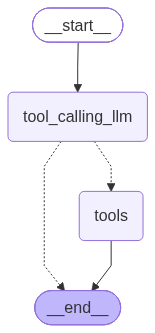

In [90]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node definition

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm) # Node name, function
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message(result) from the assistant is a tool call, then `tool_condition` routes to tools. 
    # If the latest message(result) from the assistant is not a tool call, then the tool_condition routes to end. 

    tools_condition
)

builder.add_edge("tools",END)

## compile the graph
graph= builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [91]:
response = graph.invoke({"messages":"What is the recent ai news?"})

In [92]:
response['messages'][-1].content

'{"query": "latest AI news October 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=M-z8e3eXUgs", "title": "Episode 226: Weekly AI News Summary - 04 October 2026", "content": "In today’s Weekly AI News Summary, we explore major developments shaping the future of artificial intelligence, from the White House’s shift toward the term “super intelligence” to Microsoft’s new real-time streaming transcription model and Google’s Gemini 4 Argon for advanced research and cybersecurity. Meta’s Muse sparks discussion about building AI assistants without advertisements, while OpenArm 2.0 advances open-source robotics with force-feedback capabilities. OpenAI and Synopsys are joining forces to transform semiconductor design using specialized AI models. Meanwhile, AI has reportedly helped decipher a 217-year-old letter linked to Napoleon, demonstrating its potential in historical research. Finally, India is preparing a significant 

In [93]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_f1c2fc92-5e41-4e0c-af2c-4d076cca1861)
 Call ID: fc_f1c2fc92-5e41-4e0c-af2c-4d076cca1861
  Args:
    query: latest AI news October 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news October 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=M-z8e3eXUgs", "title": "Episode 226: Weekly AI News Summary - 04 October 2026", "content": "In today’s Weekly AI News Summary, we explore major developments shaping the future of artificial intelligence, from the White House’s shift toward the term “super intelligence” to Microsoft’s new real-time streaming transcription model and Googl

In [96]:
response = graph.invoke({"messages":"what is 2 multiplied by 3"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3
================================== Ai Message ==================================

2 multiplied by 3 equals **6**.


In [98]:
response = graph.invoke({
    "messages": [
        ("user", "use the calculator tool to calculate 12345 * 6789")
    ]
})

for m in response["messages"]:
    print(type(m).__name__)
    m.pretty_print()

HumanMessage
================================ Human Message =================================

use the calculator tool to calculate 12345 * 6789
AIMessage
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_5a154989-679d-4ced-8260-c31f7d694317)
 Call ID: fc_5a154989-679d-4ced-8260-c31f7d694317
  Args:
    a: 12345
    b: 6789
ToolMessage
================================= Tool Message =================================
Name: multiply

83810205


In [104]:
response = graph.invoke({
    "messages": "what is the recent AI news and then multiply 2 by 3."
})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and then multiply 2 by 3.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_d6ebb819-606c-4df7-ad62-d6627fc6e292)
 Call ID: fc_d6ebb819-606c-4df7-ad62-d6627fc6e292
  Args:
    query: latest AI news October 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news October 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-september-2026", "title": "The latest AI news we announced in September 2026", "content": "See all in Company news \n\n       Outreach & initiatives\n\n           Creating opportunity\n           Safety & security\n           Google.org\n           Public policy\n           S

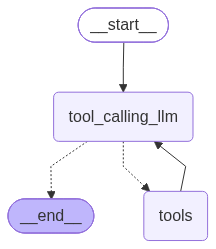

In [105]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node definition

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm) # Node name, function
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message(result) from the assistant is a tool call, then `tool_condition` routes to tools. 
    # If the latest message(result) from the assistant is not a tool call, then the tool_condition routes to end. 

    tools_condition
)

builder.add_edge("tools","tool_calling_llm") # After the tool is called, we go back to the llm node to continue the conversation

## compile the graph
graph= builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [106]:
response = graph.invoke({
    "messages": "what is the recent AI news and then multiply 2 by 3."
})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and then multiply 2 by 3.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1ff685cb-fa2e-4956-a847-89ad0cdde048)
 Call ID: fc_1ff685cb-fa2e-4956-a847-89ad0cdde048
  Args:
    query: latest AI news October 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news October 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.facebook.com/jonathanjmast/posts/%F0%9D%97%94%F0%9D%97%9C-%F0%9D%97%A1%F0%9D%97%98%F0%9D%97%AA%F0%9D%97%A6-%F0%9D%97%A7%F0%9D%97%9B%F0%9D%97%94%F0%9D%97%A7-%F0%9D%97%A0%F0%9D%97%94%F0%9D%97%A7%F0%9D%97%A7%F0%9D%97%98%F0%9D%97%A5%F0%9D%97%A6-%F0%9D%97%A7%F0%9D%97%A2-%F0%9D%97%98%F0%9D%97%A1%F0%9D%97%A7%F0%9D%97%A5%F0%9

# Adding Memory In Agentic Graph

In [113]:
response = graph.invoke({"messages":"Hello my name is sahil"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is sahil
================================== Ai Message ==================================

Hi Sahil! Nice to meet you. How can I help you today?


In [114]:
response = graph.invoke({"messages":"What is my name?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I’m sorry, but I don’t have any information about your name. If you’d like me to address you by a specific name, just let me know!
